In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern"],
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,})

In [39]:
kind = "Zero"
route_ch1 = f"{kind}/CH1.csv"
route_ch2 = f"{kind}/CH2.csv"
data_ch1 = pd.read_csv(route_ch1)
data_ch2 = pd.read_csv(route_ch2)

voltages_ch1 = data_ch1["Voltage [V]"].to_numpy()
voltages_ch2 = data_ch2["Voltage [V]"].to_numpy()
time_ch1 = data_ch1["Time [s]"].to_numpy()
time_ch2 = data_ch2["Time [s]"].to_numpy()

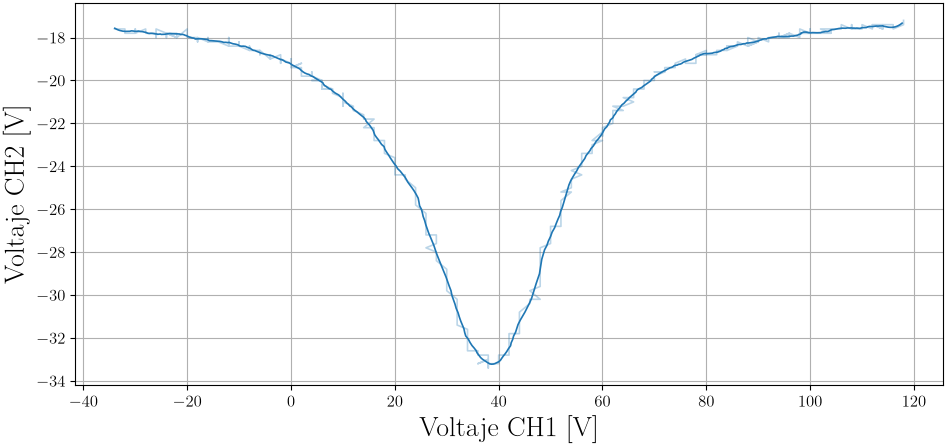

In [40]:
if kind == "Zero":
    a = 50
    b = -1
else:
    a = 20
    b = -80

vol_ch1_smooth = savgol_filter(voltages_ch1[a:b], window_length = 20, polyorder = 3)
vol_ch2_smooth = savgol_filter(voltages_ch2[a:b], window_length = 20, polyorder = 3)

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(voltages_ch1[a:b], voltages_ch2[a:b], alpha=0.3, color="#1f77b4")
ax.plot(vol_ch1_smooth, vol_ch2_smooth, color="#1f77b4")
ax.set_ylabel("Voltaje CH2 [V]")
ax.set_xlabel("Voltaje CH1 [V]")


if kind == "Peaks":
    resonancias = [(-51, r"$^{85}\mathrm{Rb}$"), (-27, r"$^{87}\mathrm{Rb}$"), (65, r"$^{87}\mathrm{Rb}$"), (92, r"$^{85}\mathrm{Rb}$")]
    for x_aprox, etiqueta in resonancias:
        mascara = np.abs(vol_ch1_smooth - x_aprox) < 4
        if np.any(mascara):
            indices_region = np.where(mascara)[0]
            indice_pico = indices_region[np.argmin(vol_ch2_smooth[mascara])]

            x_pico = vol_ch1_smooth[indice_pico]
            y_pico = vol_ch2_smooth[indice_pico]

            ax.annotate(etiqueta, xy = (x_pico, y_pico), xytext = (0, -25), textcoords = "offset points", ha = "center", va = "top", fontsize = 11, fontweight = "bold", color = "black", arrowprops = dict(arrowstyle = "->", color = "black", lw = 2), bbox = dict(boxstyle = "round,pad = 0.2", facecolor = "white", edgecolor = "gray", alpha = 0.85))

ax.grid(True)
plt.tight_layout()
plt.savefig(f"{kind}.pdf", bbox_inches = "tight")
plt.show()